In [16]:
from FormUtils import pyForm, capture_physics_expr

In [17]:
%%pyForm WDecay

* Process: W -> fermion neutrino

#-
* Above suppresses extra output
Off Statistics;
Off FinalStats;
#include FeynHelpers.h

* Massess
Symbols  ml, mW, gW, sqrt2;
* Polarization 4-vector
Vector n, x, y;


* unpolarized
Local M =   (gW^2/(2 * sqrt2)) * UB(i1, p2, ml) 
            *  (gamma(i1, i3, mu1)-gamma(i1, i2, k5) * gamma(i2, i3, mu1))  
            *  V(i3, p3, 0) * esumM(mu1,q,mW);
#call squareamplitude(M, Msq)
multiply 1/3;
.sort

* polarized
Local MNoPol =  (gW^2/(2 * sqrt2)) * UB(i1, p2, ml) *  (gamma(i1, i3, mu1)-gamma(i1, i2, k5) * gamma(i2, i3, mu1))  * V(i3, p3, 0) ;
Local MPolZ = MNoPol * VpolZ(mu1, q, n, mW); 
Local MPolL = MNoPol * VpolL(mu1, q, n, mW); 
Local MPolR = MNoPol * VpolR(mu1, q, n, mW);  

#call squareamplitude(MPolZ, MsqPolZ)
#call squareamplitude(MPolL, MsqPolL)
#call squareamplitude(MPolR, MsqPolR)
.sort

id sqrt2^-2 = 1/2;
.sort
id e_(q, n, mu1, mu2) * e_(p2, p3, mu1, mu2) = -2 * (q.p2 * n.p3 - q.p3 * n.p2);
.sort
id n.n = -1 ;
.sort

* --- Kinematics ---
id q.q = mW^2;
id p3.p3 = 0;
id p2.p3 = (mW^2 - ml^2)/2;
id q.p2 = (mW^2 + ml^2)/2;
id q.p3 = (mW^2 - ml^2)/2;
.sort


* Save to file 
Format C;
#write <../Results/WDecay.txt> "%e;", Msq;
#write <../Results/WDecayPolZ.txt> "%e;", MsqPolZ;
#write <../Results/WDecayPolL.txt> "%e;", MsqPolL;
#write <../Results/WDecayPolR.txt> "%e;", MsqPolR;
.sort
* Print 
Format;
Print Msq;
Print MsqPolZ;
Print MsqPolL;
Print MsqPolR;

.end

FORM 5.0.0 (Jan 27 2026, v5.0.0)                 Run: Sun May 31 21:29:35 2026
    
    * Process: W -> fermion neutrino
    
    #-
    

   Msq =
      1/3*mW^2*gW^4 - 1/6*ml^2*gW^4 - 1/6*ml^4*mW^(-2)*gW^4;

   MsqPolZ =
      1/2*mW^2*gW^4 - 1/2*ml^2*gW^4 + 2*p2.n*p3.n*gW^4;

   MsqPolL =
      1/4*mW^2*gW^4 - 1/4*ml^4*mW^(-2)*gW^4 - p2.n*p3.n*gW^4 - 1/2*p2.n*mW*
      gW^4 + 1/2*p2.n*ml^2*mW^(-1)*gW^4 + 1/2*p3.n*mW*gW^4 + 1/2*p3.n*ml^2*
      mW^(-1)*gW^4;

   MsqPolR =
      1/4*mW^2*gW^4 - 1/4*ml^4*mW^(-2)*gW^4 - p2.n*p3.n*gW^4 + 1/2*p2.n*mW*
      gW^4 - 1/2*p2.n*ml^2*mW^(-1)*gW^4 - 1/2*p3.n*mW*gW^4 - 1/2*p3.n*ml^2*
      mW^(-1)*gW^4;




Msq :
  4   2
gW ⋅mW 
───────
   3   


Msq_L :
  4   2             2
gW ⋅mW ⋅(cos(θ) + 1) 
─────────────────────
          4          


Msq_R :
  4   2             2
gW ⋅mW ⋅(cos(θ) - 1) 
─────────────────────
          4          


Msq_0 :
  4   2    2   
gW ⋅mW ⋅sin (θ)
───────────────
       2       


0




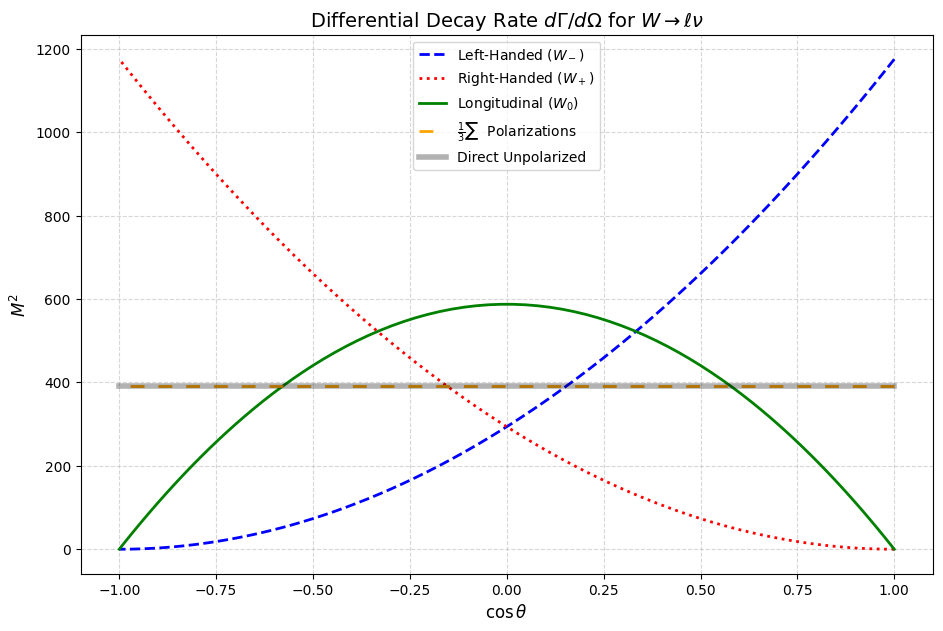

In [18]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from Kinematics import dGamma_dOmega

plt.style.use("seaborn-v0_8-muted")
plt.rcParams["axes.grid"] = True

# Unpolarized
form_expr = capture_physics_expr("WDecay.txt")
mW, gW, ml = sp.symbols("mW gW ml")
Msq = sp.simplify(form_expr, rational=True).subs(ml, 0)
print(f"Msq :")
sp.pprint(Msq, num_columns=80)
print("\n")

# Polarized
form_expr_PolZ = capture_physics_expr("WDecayPolZ.txt")
form_expr_PolL = capture_physics_expr("WDecayPolL.txt")
form_expr_PolR = capture_physics_expr("WDecayPolR.txt")
p2_n, p3_n = sp.symbols("p2_n, p3_n")
Msq_PolZ = sp.simplify(form_expr_PolZ, rational=True).subs(ml, 0)
Msq_PolL = sp.simplify(form_expr_PolL, rational=True).subs(ml, 0)
Msq_PolR = sp.simplify(form_expr_PolR, rational=True).subs(ml, 0)

# p2 (Lepton)  = [E_lep, p_mag*sin(theta), 0, p_mag*cos(theta)]
# p3 (Neutrino)= [p_mag, -p_mag*sin(theta), 0, -p_mag*cos(theta)]
# p_mag = mW / 2
# n is [0, 0,0,1]
theta = sp.Symbol("theta", real=True)
subs = {
    p2_n: -(mW / 2) * sp.cos(theta),
    p3_n: (mW / 2) * sp.cos(theta),  # p3 is opposite to p2 in rest frame
}

Msq_L = sp.simplify(Msq_PolL.subs(subs))
Msq_R = sp.simplify(Msq_PolR.subs(subs))
Msq_0 = sp.simplify(Msq_PolZ.subs(subs))
print(f"Msq_L :")
sp.pprint(Msq_L, num_columns=80)
print("\n")
print(f"Msq_R :")
sp.pprint(Msq_R, num_columns=80)
print("\n")
print(f"Msq_0 :")
sp.pprint(Msq_0, num_columns=80)
print("\n")

# Check that they cancel, account for averaging
diff = sp.simplify(Msq_L + Msq_R +  Msq_0 - 3*Msq)
sp.pprint(diff, num_columns=80)
print("\n")


physics_vals = {mW: 80.379, gW: 0.653}
angles = np.linspace(0, np.pi, 100)
x_vals = np.cos(angles)
f_L = sp.lambdify(theta, Msq_L.subs(physics_vals), "numpy")
f_R = sp.lambdify(theta, Msq_R.subs(physics_vals), "numpy")
f_0 = sp.lambdify(theta, Msq_0.subs(physics_vals), "numpy")

pol_L = f_L(angles)
pol_R = f_R(angles)
pol_0 = f_0(angles)
sumAvgPol = (pol_L + pol_R + pol_0) / 3

unpol = np.full_like(angles, Msq.subs(physics_vals).evalf())

plt.figure(figsize=(11, 7))
# Plot Individual Polarizations
plt.plot(
    x_vals, pol_L, label=r"Left-Handed ($W_-$)", linestyle="--", color="blue", lw=2
)
plt.plot(x_vals, pol_R, label=r"Right-Handed ($W_+$)", linestyle=":", color="red", lw=2)
plt.plot(
    x_vals, pol_0, label=r"Longitudinal ($W_0$)", linestyle="-", color="green", lw=2
)
plt.plot(
    x_vals,
    sumAvgPol,
    label=r"$\frac{1}{3} \sum$  Polarizations",
    color="orange",
    ls=(0, (5, 5)),
    lw=2,
)
plt.plot(x_vals, unpol, label="Direct Unpolarized", color="black", lw=4, alpha=0.3)

# Formatting
plt.title(
    r"Differential Decay Rate $d\Gamma/d\Omega$ for $W \to \ell \nu$", fontsize=14
)
plt.xlabel(r"$\cos \theta$ ", fontsize=12)
plt.ylabel(r"$M^2$", fontsize=12)
plt.legend(frameon=True, loc="upper center")
plt.grid(True, which="both", linestyle="--", alpha=0.5)